# **Makemore: Multi-Layer Perceptrons**
Scales the ideas from Micrograd and Makemore: Bigrams into a true multi-layer neural network with a hidden layer and non-linear activation functions. Model moves past and beyond static counting. Introduces data splitting, hyperparameter tuning, under and overfitting, etc. 

**Paper Followed:** A Neural Probabilistic Language Model - Bengio et al. 2003

## **Building Data-Set**

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build vocab of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi= {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [34]:
block_size = 3 # context length: how many chars do we take to predict the next one
X, Y = [], []
for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

EXAMPLE:

emma

... ---> e

..e ---> m

.em ---> m

emm ---> a

mma ---> .

## **Embedding Look-Up Table**
Like the Weight matrix

In [9]:
# each 27 chars will have 2 dimensional embedding
# gives each character a (x, y) coordinate pair
C = torch.randn((27, 2))

In [10]:
C[5]

# Under the hood:
# F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-1.2749,  0.0374])

In [11]:
C[[5, 6, 7]]

tensor([[-1.2749,  0.0374],
        [ 0.7963,  2.5561],
        [-1.1307, -1.3095]])

In [12]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

## **Hidden Layer**

In [13]:
# 3 context characters with 2 embedding dimensions each
# and 100 hidden neurons:
W1 = torch.randn((6,100)) 
# bias term for each of the 100 neurons
b1 = torch.randn(100)

In [14]:
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)
# torch.cat(torch.unbind(emb, 1), 1)

In [15]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [16]:
# PyTorch doesn't actually copy or move the underlying data in memory, it just changes the viewfinder
a.view(2, 9)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [17]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 6) --> (-1, 6) so it's not hardcoded and program will determine dimensions on its own
h

tensor([[-0.9883,  0.5988,  0.9206,  ...,  0.7582,  0.9039,  0.9999],
        [-0.9546, -0.1421,  0.8803,  ..., -0.3565,  0.9175,  0.9891],
        [-0.9994,  0.9527,  0.0244,  ...,  0.9961,  0.9252,  0.9979],
        ...,
        [ 0.9374,  0.6167, -0.9998,  ...,  0.9866, -0.9729, -0.9998],
        [ 1.0000, -0.9984, -0.8865,  ..., -0.9796,  0.9743, -1.0000],
        [-0.8846,  1.0000,  0.9133,  ...,  1.0000,  0.9996,  1.0000]])

## **Output Layer**

In [18]:
# takes 100 features coming out of hidden layer
# projects them onto 27 dimensions, one for every letter plus dot token
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [ ]:
logits = h @ W2 + b2
# represents how much the model "prefers" each of the 27 chars to come next
logits

In [21]:
counts = logits.exp()

In [22]:
prob = counts / counts.sum(1, keepdims=True)

In [23]:
prob[0].sum()

tensor(1.0000)

In [24]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [25]:
# extracting what the model got correct
# for each 32 sample, extracts probability of predicting correct "Y" (next char in sequence after 3 context chars)
prob[torch.arange(32), Y]

tensor([1.1525e-04, 2.0169e-06, 1.6907e-03, 5.3090e-08, 4.7739e-06, 6.0225e-04,
        3.0884e-07, 1.4042e-02, 1.4545e-07, 4.0051e-09, 4.4781e-08, 2.1229e-06,
        5.9457e-04, 7.4803e-07, 9.5339e-07, 6.7064e-11, 7.5089e-04, 1.2127e-02,
        2.3500e-05, 1.0883e-13, 3.4474e-13, 1.1369e-03, 5.9820e-13, 1.3484e-09,
        1.0619e-11, 6.1207e-03, 4.9147e-06, 1.3141e-06, 7.3572e-14, 8.3716e-04,
        5.3858e-07, 1.5230e-09])

In [26]:
# negative log-likelihood loss
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(14.7649)

## **Respectable Version**

In [35]:
X.shape, Y.shape  # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [144]:
g = torch.Generator().manual_seed(2147483647)   # for reproducibility
C = torch.randn((27, 2), generator=g)           # embdedding table          | shape: (27 chars, 2 embedding features each)
W1 = torch.randn((6, 100), generator=g)         # hidden layer weights      | (6 input features, 100 hidden neurons)
b1 = torch.randn(100, generator=g)              # hidden layer bias         | 100 values, 1 for each hidden neuron
W2 = torch.randn((100, 27), generator=g)        # output layer weights      | (100 inputs coming in, 27 chars)
b2 = torch.randn(27, generator=g)               # output layer bias         | 27 values, one for each char
# optimizer - when training model, instead of individually updating each matrix, this list can tune everything at once
parameters = [C, W1, b1, W2, b2]                

In [145]:
sum(p.nelement() for p in parameters)  # number of parameters in total

3481

In [146]:
emb = C[X]  # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)

# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(32), Y].log().mean()

# shortcut: doesn't create tensors that'll take up memory, backward pass will be more efficient
loss = F.cross_entropy(logits, Y) # arguements: (model's predictions, target labels)
loss

tensor(19.5052)

## **Training Loop**
Before training a model, check: can the model successfully overfit a single, tiny batch of data?

A model with 3,481 parameters should easily be able to memorize 32 examples. Loss should plummet all the way down to 0.0

In [147]:
for p in parameters:
    p.requires_grad = True

### **"Fitting these 32 examples"**
Using optimization (gradient descent) to tune model's parameters so that its error on that specific subset of data drops as close to zero as possible

In [148]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre


In [151]:
# keeping track of learning weight and resulting losses
lri = []
lossi = []


for i in range(1000):

    # mini-batch constructor
    ix = torch.randint(0, X.shape[0], (32, ))

    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Y[ix]) 
    # print(loss.item())

# backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

# update
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())

loss

# can't get to exactly zero | "..." --> predicting several chars

tensor(2.3376, grad_fn=<NllLossBackward0>)

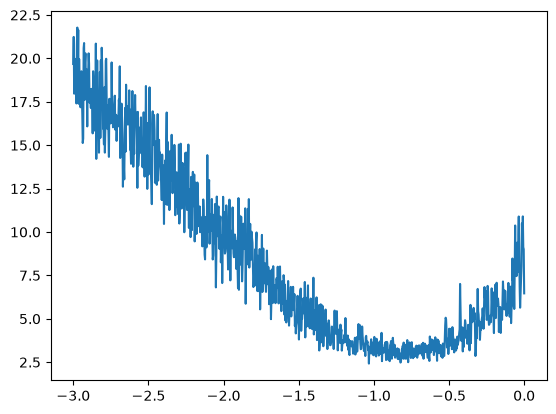

In [143]:
plt.plot(lri, lossi)

In [ ]:
# evalutes the whole data set, compared to evaluting by mini-batches above
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3438, grad_fn=<NllLossBackward0>)

## **Splitting Data**
- Training split
- Dev/val split
- Test split